# Electric Vehicle Battery Failure Classification — Complete End-to-End Project (EDA & Machine Learning)

---

## 1. Project Introduction

### Project Title
**Electric Vehicle (EV) Battery Failure Classification and Health Analysis**

### Project Overview
This notebook presents a complete, end-to-end Data Science and Machine Learning project for predicting electric vehicle (EV) battery failure:
* **Part 1: Exploratory Data Analysis (EDA)** — Deep-dive statistical analysis, distribution modeling, correlation analysis, and multicollinearity pruning (Sections 1–16).
* **Part 2: Machine Learning Modeling (NO PIPELINES)** — Step-by-step data preprocessing, manual imputation, one-hot encoding, scaling, training 6 classification algorithms, baseline evaluation, 5-fold hyperparameter tuning, model comparison, feature importance, and model serialization (Sections 17–34).

### Objective
The goal of this project is to perform comprehensive data analysis and build a machine learning model to classify whether an EV battery pack is **Healthy (`0`)** or **Failed / Failing (`1`)** based on internal physical measurements, operational telemetry, and pack characteristics.

### What Battery Failure Classification Means
Battery failure classification is a **supervised binary classification** problem in data science. The target variable is `battery_failure`:
* **0 (Healthy)**: The battery pack operates normally within safe health thresholds.
* **1 (Failed)**: The battery pack has suffered degradation or anomalies warranting maintenance inspection, decommissioning, or replacement.

### Why Predicting EV Battery Failure is Useful
* **Predictive Maintenance**: EV manufacturers and fleet operators can schedule proactive servicing before unscheduled on-road breakdowns occur.
* **Safety & Hazard Prevention**: Early detection of severe degradation prevents catastrophic operational failures.
* **Cost & Warranty Optimization**: Identifying pack health issues early reduces full replacement costs and optimizes warranty claims.
* **Second-Life Assessment**: Helps screen whether retired EV batteries are suitable for stationary energy storage systems.

---

## 2. Import Libraries

### What we are doing
We import the foundational Python libraries for data manipulation, numerical computing, and statistical data visualization.

### Why we are doing it
* `pandas`: For tabular data operations and DataFrames.
* `numpy`: For numerical computations and array manipulations.
* `matplotlib.pyplot` & `seaborn`: For creating clean, informative statistical charts.

In [1]:
# Import data manipulation and statistical libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure default visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


---

## 3. Load Dataset

### What we are doing
We load the EV battery dataset (`ev_battery_health_subset(3).csv`) into a pandas DataFrame and inspect its dimensions, headers, and first few rows.

In [2]:
# Load the EV battery dataset from CSV
df = pd.read_csv("ev_battery_health_subset(3).csv")

In [3]:
# Display the first 5 rows
df.head()

,vehicle_brand,vehicle_type,battery_chemistry,drive_type,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge,battery_failure
0,Nissan,SUV,NaN,AWD,544.0,195563.0,11.17,48.64,0.03349,0.8556,67.6,4.7,59.6,NaN,71.45,11.48,1
1,Tata,Truck,NMC,FWD,1.0,500.0,9.91,0.20,0.01395,0.4191,48.3,41.4,3.0,2016.0,113.53,42.52,0
2,Ford,Sedan,NMC,NaN,584.0,191310.0,6.23,31.01,0.02689,0.6125,58.8,40.5,111.0,2020.0,67.40,11.89,1
3,Tesla,Sedan,NCA,RWD,NaN,107869.0,7.80,17.07,0.02580,0.4472,60.9,41.0,53.4,2018.0,77.72,54.00,0
4,GM,Hatchback,LFP,RWD,1.0,4970.0,5.96,2.86,0.01572,0.5883,28.4,58.4,3.0,2020.0,49.02,49.09,0


In [4]:
# Display the last 5 rows
df.tail()

,vehicle_brand,vehicle_type,battery_chemistry,drive_type,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge,battery_failure
3995,Tesla,SUV,NMC,FWD,927.0,432659.0,10.15,47.79,0.03646,0.8344,67.3,84.6,140.9,2016.0,NaN,58.90,1
3996,GM,Sedan,NMC,FWD,714.0,257903.0,5.97,33.77,0.02833,0.6587,56.1,46.0,139.9,2020.0,68.43,52.46,1
3997,Nissan,Sedan,NMC,AWD,835.0,372248.0,10.10,46.68,0.03755,0.7640,84.0,65.2,118.0,2016.0,81.79,41.25,1
3998,GM,Truck,LFP,FWD,138.0,76500.0,4.58,3.82,0.01645,0.5955,21.6,31.5,58.6,2021.0,121.33,37.75,0
3999,NaN,Sedan,NMC,RWD,80.0,38179.0,5.05,0.20,0.01531,0.4160,48.0,20.3,NaN,2021.0,87.10,54.83,0


In [5]:
# Display the shape of the dataset (rows, columns)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.shape

Dataset Shape: 4000 rows, 17 columns


(4000, 17)

In [6]:
# Display all column names
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['vehicle_brand', 'vehicle_type', 'battery_chemistry', 'drive_type', 'cycle_count', 'odometer_km', 'vehicle_age_years', 'capacity_loss_percent', 'cell_voltage_std', 'internal_resistance', 'thermal_runaway_risk', 'battery_stress_index', 'daily_distance', 'manufacturing_year', 'battery_capacity_kwh', 'depth_of_discharge', 'battery_failure']


---

## 4. Basic Dataset Information

### What we are doing
We inspect the structural metadata of the dataset using `df.info()`, `df.describe()`, and `df.dtypes`.

In [7]:
# Display concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   vehicle_brand          3849 non-null   object 
 1   vehicle_type           3866 non-null   object 
 2   battery_chemistry      3849 non-null   object 
 3   drive_type             3879 non-null   object 
 4   cycle_count            3842 non-null   float64
 5   odometer_km            3834 non-null   float64
 6   vehicle_age_years      3833 non-null   float64
 7   capacity_loss_percent  3797 non-null   float64
 8   cell_voltage_std       3823 non-null   float64
 9   internal_resistance    3834 non-null   float64
 10  thermal_runaway_risk   3870 non-null   float64
 11  battery_stress_index   3847 non-null   float64
 12  daily_distance         3820 non-null   float64
 13  manufacturing_year     3800 non-null   float64
 14  battery_capacity_kwh   3833 non-null   float64
 15  dept

In [8]:
# Display descriptive statistics for all columns
df.describe()

,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge,battery_failure
count,3842.000000,3834.000000,3833.000000,3797.000000,3823.000000,3834.000000,3870.000000,3847.000000,3820.000000,3800.000000,3833.000000,3833.000000,4000.000000
mean,496.074961,163962.594418,7.554813,23.265267,0.023707,0.628744,56.766615,44.258877,70.213979,2018.426316,73.383222,39.665220,0.500000
std,391.822108,113789.048135,2.794048,16.922119,0.010190,0.192598,19.236865,24.319042,38.779435,2.775602,21.019370,12.607774,0.500063
min,1.000000,500.000000,1.610000,0.200000,0.001000,0.082245,4.900000,0.000000,3.000000,2015.000000,25.000000,5.000000,0.000000
25%,182.250000,64876.250000,5.180000,7.400000,0.015310,0.520350,47.700000,26.700000,39.100000,2016.000000,58.380000,30.980000,0.000000
50%,425.500000,150667.500000,8.040000,22.780000,0.023900,0.620700,60.600000,42.100000,69.850000,2018.000000,72.250000,39.670000,0.500000
75%,721.000000,246834.250000,9.980000,36.920000,0.031665,0.721300,70.000000,59.350000,101.025000,2021.000000,87.670000,48.340000,1.000000
max,3200.000000,450000.000000,11.460000,71.180000,0.053080,3.882900,100.000000,100.000000,192.600000,2024.000000,141.060000,83.490000,1.000000


In [9]:
# Display the data types of each column
df.dtypes

vehicle_brand             object
vehicle_type              object
battery_chemistry         object
drive_type                object
cycle_count              float64
odometer_km              float64
vehicle_age_years        float64
capacity_loss_percent    float64
cell_voltage_std         float64
internal_resistance      float64
thermal_runaway_risk     float64
battery_stress_index     float64
daily_distance           float64
manufacturing_year       float64
battery_capacity_kwh     float64
depth_of_discharge       float64
battery_failure            int64
dtype: object

### Summary of Dataset Structure

* **Total Records**: 4,000 observations (rows).
* **Total Columns**: 17 columns (16 predictor features + 1 target).
* **Categorical Predictor Features (4)**: `vehicle_brand`, `vehicle_type`, `battery_chemistry`, `drive_type`.
* **Numerical Predictor Features (12)**: `cycle_count`, `odometer_km`, `vehicle_age_years`, `capacity_loss_percent`, `cell_voltage_std`, `internal_resistance`, `thermal_runaway_risk`, `battery_stress_index`, `daily_distance`, `manufacturing_year`, `battery_capacity_kwh`, `depth_of_discharge`.
* **Target Column (1)**: `battery_failure` (0 = Healthy, 1 = Failed).

---

## 5. Data Quality Check

### What we are doing
We check for missing (`NaN`) values, duplicate rows, and unique category distributions across the dataset.

In [10]:
# Count missing values per column
df.isnull().sum()

vehicle_brand            151
vehicle_type             134
battery_chemistry        151
drive_type               121
cycle_count              158
odometer_km              166
vehicle_age_years        167
capacity_loss_percent    203
cell_voltage_std         177
internal_resistance      166
thermal_runaway_risk     130
battery_stress_index     153
daily_distance           180
manufacturing_year       200
battery_capacity_kwh     167
depth_of_discharge       167
battery_failure            0
dtype: int64

In [11]:
# Calculate the percentage of missing values per column
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percent.round(2)
})

# Display columns sorted by missing count descending
missing_table.sort_values(by="Missing Count", ascending=False)

,Missing Count,Missing Percentage (%)
capacity_loss_percent,203,5.08
manufacturing_year,200,5.00
daily_distance,180,4.50
cell_voltage_std,177,4.42
depth_of_discharge,167,4.18
vehicle_age_years,167,4.18
battery_capacity_kwh,167,4.18
internal_resistance,166,4.15
odometer_km,166,4.15
cycle_count,158,3.95


In [12]:
# Check for duplicate rows across the entire dataset
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


In [13]:
# Check unique value counts for categorical columns and target
print("--- Vehicle Brand Value Counts ---")
print(df["vehicle_brand"].value_counts(dropna=False))
print("\n--- Vehicle Type Value Counts ---")
print(df["vehicle_type"].value_counts(dropna=False))
print("\n--- Battery Chemistry Value Counts ---")
print(df["battery_chemistry"].value_counts(dropna=False))
print("\n--- Drive Type Value Counts ---")
print(df["drive_type"].value_counts(dropna=False))
print("\n--- Target: Battery Failure Value Counts ---")
print(df["battery_failure"].value_counts(dropna=False))

--- Vehicle Brand Value Counts ---
vehicle_brand
Tesla         525
BYD           293
Volkswagen    287
Hyundai       238
Nissan        233
BMW           210
Mercedes      202
Kia           201
GM            191
Renault       188
Ford          177
Toyota        169
Audi          156
NaN           151
Tata          140
Volvo         138
Rivian        124
Honda         105
MG            103
Lucid          85
Mahindra       84
Name: count, dtype: int64

--- Vehicle Type Value Counts ---
vehicle_type
SUV          1058
Sedan         859
Hatchback     841
Crossover     656
Truck         233
Van           219
NaN           134
Name: count, dtype: int64

--- Battery Chemistry Value Counts ---
battery_chemistry
NMC    2458
LFP     700
NCA     474
LMO     194
NaN     151
LTO      23
Name: count, dtype: int64

--- Drive Type Value Counts ---
drive_type
FWD    1757
AWD    1143
RWD     979
NaN     121
Name: count, dtype: int64

--- Target: Battery Failure Value Counts ---
battery_failure
1    2000
0

### Data Quality Findings

1. **Missing Values**: Features contain a small proportion of missing values ranging between **3.0% and 5.1%** (approx. 120 to 203 missing values per column). The target column `battery_failure` has **0 missing values** (100% complete).
2. **Duplicate Records**: There are **0 duplicate rows** in the dataset.
3. **Categorical Consistency**: Valid categories across brands, types, chemistries, and drive types.

---

## 6. Target Variable Analysis

### What we are doing
We analyze the distribution of the target column (`battery_failure`) by calculating exact counts, percentages, and plotting a count plot.

In [14]:
# Count and percentage of each target class
target_counts = df["battery_failure"].value_counts()
target_percentages = df["battery_failure"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Class Label": ["Healthy (0)", "Failed (1)"],
    "Count": [target_counts[0], target_counts[1]],
    "Percentage (%)": [target_percentages[0], target_percentages[1]]
})

target_summary

,Class Label,Count,Percentage (%)
0,Healthy (0),2000,50.0
1,Failed (1),2000,50.0


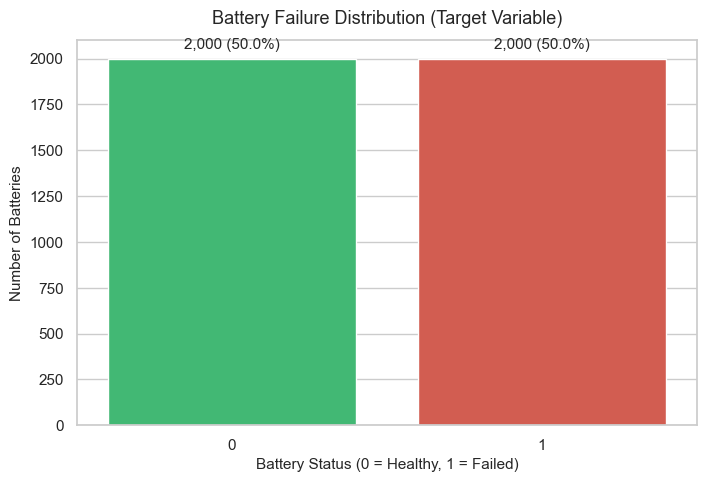

In [15]:
# Visualize target variable distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x="battery_failure",
    data=df,
    palette=["#2ecc71", "#e74c3c"]
)

plt.title("Battery Failure Distribution (Target Variable)", fontsize=13, pad=12)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=11)
plt.ylabel("Number of Batteries", fontsize=11)

# Annotate exact bar values on the plot
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height:,} ({height/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., height),
                ha="center", va="bottom", fontsize=11, xytext=(0, 5), textcoords="offset points")

plt.show()

### Target Variable Interpretation

* **Healthy Batteries (`0`)**: 2,000 samples (50.0%)
* **Failed Batteries (`1`)**: 2,000 samples (50.0%)

**Conclusion on Class Balance**:
The target variable is **balanced (50% / 50%)**. Standard classification metrics such as **Accuracy, Precision, Recall, F1-Score, and ROC-AUC** provide direct and informative evaluation without requiring synthetic resampling.

---

## 7. Numerical Feature Overview

### What we are doing
We inspect the summary statistics (mean, median, standard deviation, minimum, and maximum) for all 12 numerical predictor features in the dataset.

In [16]:
# List all 12 numerical predictor features in the raw dataset
all_numerical_features = [
    "cycle_count",
    "odometer_km",
    "vehicle_age_years",
    "capacity_loss_percent",
    "cell_voltage_std",
    "internal_resistance",
    "thermal_runaway_risk",
    "battery_stress_index",
    "daily_distance",
    "manufacturing_year",
    "battery_capacity_kwh",
    "depth_of_discharge"
]

print(f"Total numerical predictor features in raw dataset: {len(all_numerical_features)}")

Total numerical predictor features in raw dataset: 12


In [17]:
# Display descriptive statistics for all 12 numerical features
df[all_numerical_features].describe().round(2)

,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge
count,3842.00,3834.00,3833.00,3797.00,3823.00,3834.00,3870.00,3847.00,3820.00,3800.00,3833.00,3833.00
mean,496.07,163962.59,7.55,23.27,0.02,0.63,56.77,44.26,70.21,2018.43,73.38,39.67
std,391.82,113789.05,2.79,16.92,0.01,0.19,19.24,24.32,38.78,2.78,21.02,12.61
min,1.00,500.00,1.61,0.20,0.00,0.08,4.90,0.00,3.00,2015.00,25.00,5.00
25%,182.25,64876.25,5.18,7.40,0.02,0.52,47.70,26.70,39.10,2016.00,58.38,30.98
50%,425.50,150667.50,8.04,22.78,0.02,0.62,60.60,42.10,69.85,2018.00,72.25,39.67
75%,721.00,246834.25,9.98,36.92,0.03,0.72,70.00,59.35,101.02,2021.00,87.67,48.34
max,3200.00,450000.00,11.46,71.18,0.05,3.88,100.00,100.00,192.60,2024.00,141.06,83.49


---

## 8. Distribution of Key Numerical Features

### What we are doing
We plot individual histograms with Kernel Density Estimation (KDE) overlays for key continuous battery health and operational features to inspect distributions, central tendencies, and spread.

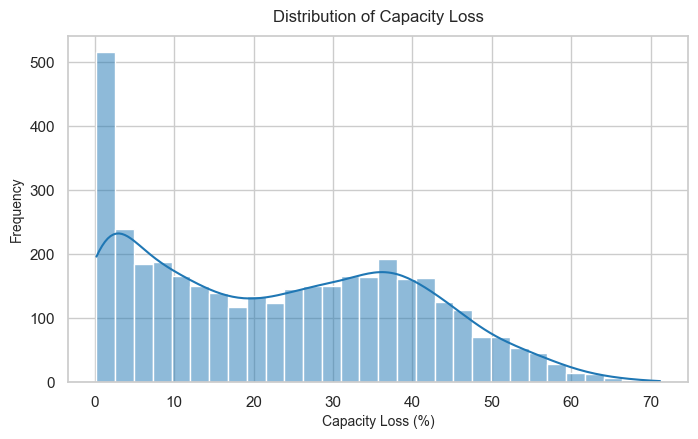

In [18]:
# Plot distribution for capacity_loss_percent
plt.figure(figsize=(8, 4.5))
sns.histplot(df["capacity_loss_percent"].dropna(), kde=True, color="#1f77b4", bins=30)
plt.title("Distribution of Capacity Loss", fontsize=12, pad=10)
plt.xlabel("Capacity Loss (%)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

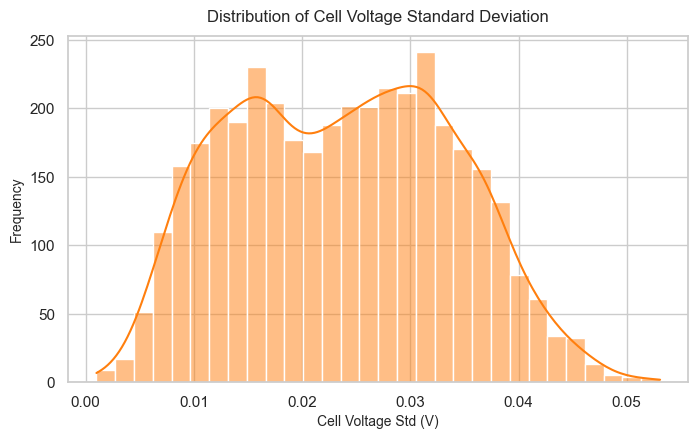

In [19]:
# Plot distribution for cell_voltage_std
plt.figure(figsize=(8, 4.5))
sns.histplot(df["cell_voltage_std"].dropna(), kde=True, color="#ff7f0e", bins=30)
plt.title("Distribution of Cell Voltage Standard Deviation", fontsize=12, pad=10)
plt.xlabel("Cell Voltage Std (V)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

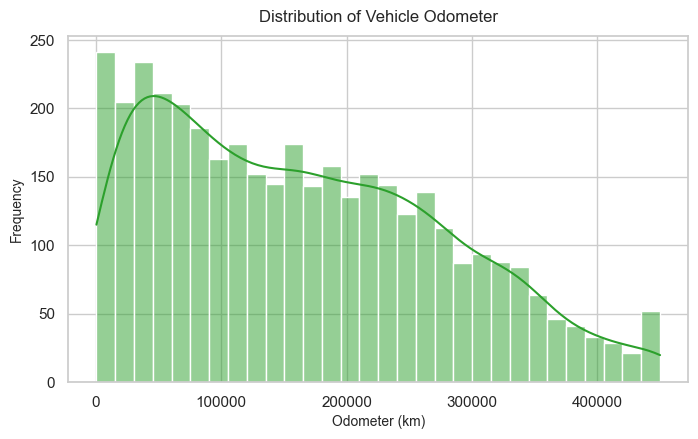

In [20]:
# Plot distribution for odometer_km
plt.figure(figsize=(8, 4.5))
sns.histplot(df["odometer_km"].dropna(), kde=True, color="#2ca02c", bins=30)
plt.title("Distribution of Vehicle Odometer", fontsize=12, pad=10)
plt.xlabel("Odometer (km)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

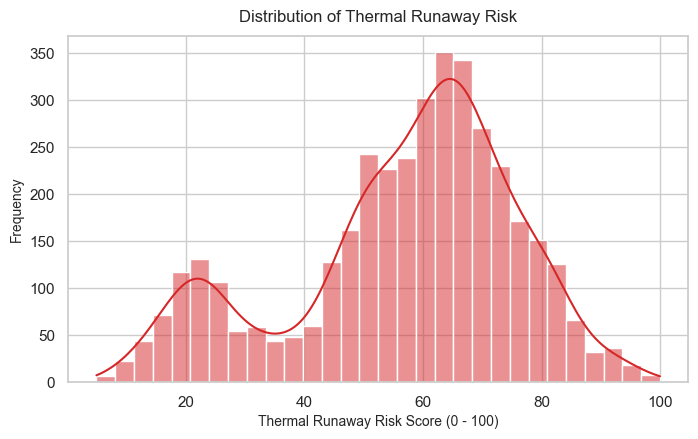

In [21]:
# Plot distribution for thermal_runaway_risk
plt.figure(figsize=(8, 4.5))
sns.histplot(df["thermal_runaway_risk"].dropna(), kde=True, color="#d62728", bins=30)
plt.title("Distribution of Thermal Runaway Risk", fontsize=12, pad=10)
plt.xlabel("Thermal Runaway Risk Score (0 - 100)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

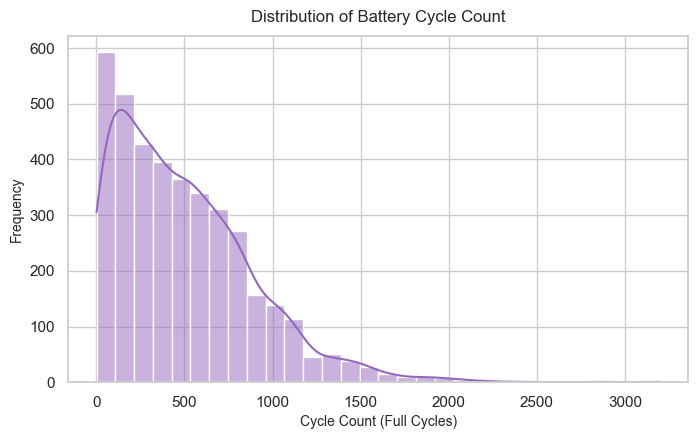

In [22]:
# Plot distribution for cycle_count
plt.figure(figsize=(8, 4.5))
sns.histplot(df["cycle_count"].dropna(), kde=True, color="#9467bd", bins=30)
plt.title("Distribution of Battery Cycle Count", fontsize=12, pad=10)
plt.xlabel("Cycle Count (Full Cycles)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

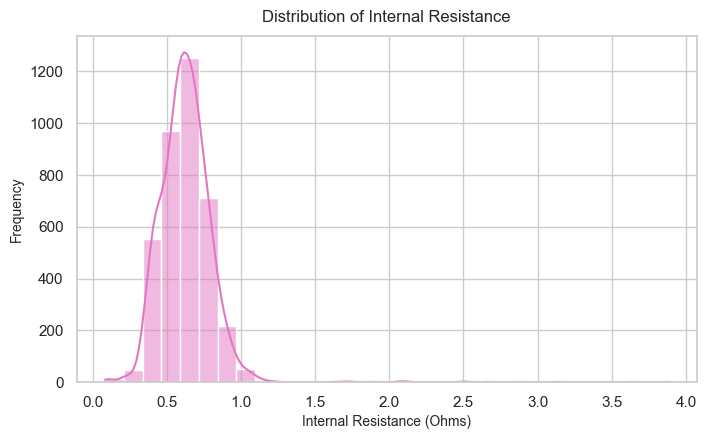

In [23]:
# Plot distribution for internal_resistance
plt.figure(figsize=(8, 4.5))
sns.histplot(df["internal_resistance"].dropna(), kde=True, color="#e377c2", bins=30)
plt.title("Distribution of Internal Resistance", fontsize=12, pad=10)
plt.xlabel("Internal Resistance (Ohms)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

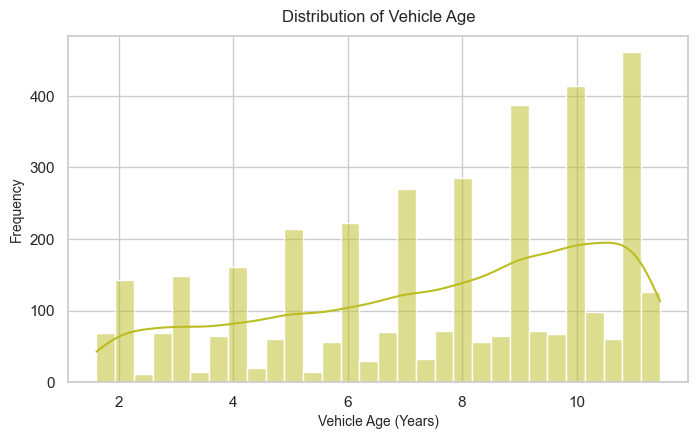

In [24]:
# Plot distribution for vehicle_age_years
plt.figure(figsize=(8, 4.5))
sns.histplot(df["vehicle_age_years"].dropna(), kde=True, color="#bcbd22", bins=30)
plt.title("Distribution of Vehicle Age", fontsize=12, pad=10)
plt.xlabel("Vehicle Age (Years)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

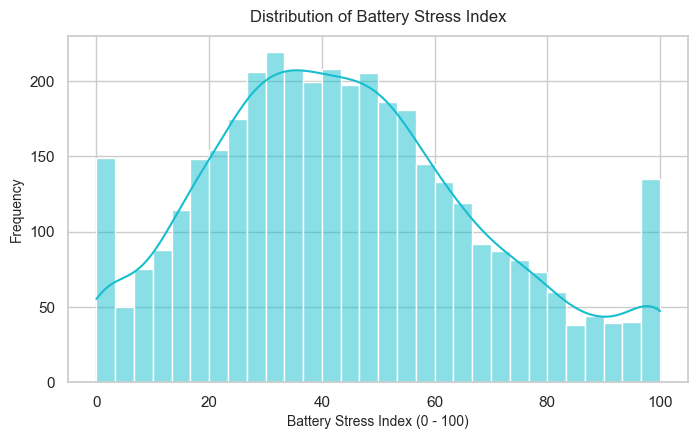

In [25]:
# Plot distribution for battery_stress_index
plt.figure(figsize=(8, 4.5))
sns.histplot(df["battery_stress_index"].dropna(), kde=True, color="#17becf", bins=30)
plt.title("Distribution of Battery Stress Index", fontsize=12, pad=10)
plt.xlabel("Battery Stress Index (0 - 100)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

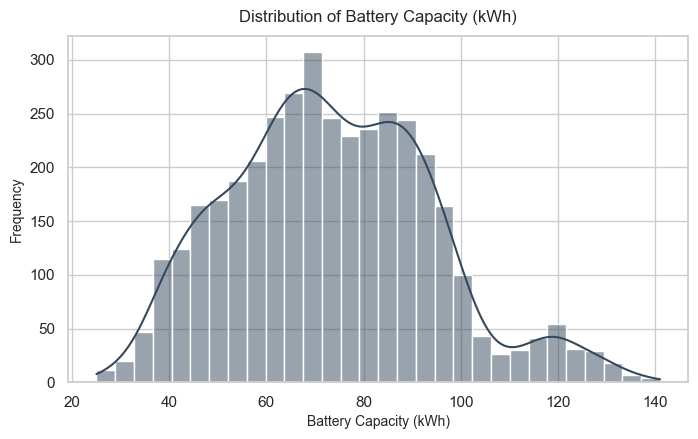

In [26]:
# Plot distribution for battery_capacity_kwh
plt.figure(figsize=(8, 4.5))
sns.histplot(df["battery_capacity_kwh"].dropna(), kde=True, color="#34495e", bins=30)
plt.title("Distribution of Battery Capacity (kWh)", fontsize=12, pad=10)
plt.xlabel("Battery Capacity (kWh)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

---

## 9. Numerical Features vs Battery Failure

### What we are doing
We create comparative boxplots showing the relationship between key numerical features and `battery_failure` (0 = Healthy, 1 = Failed).

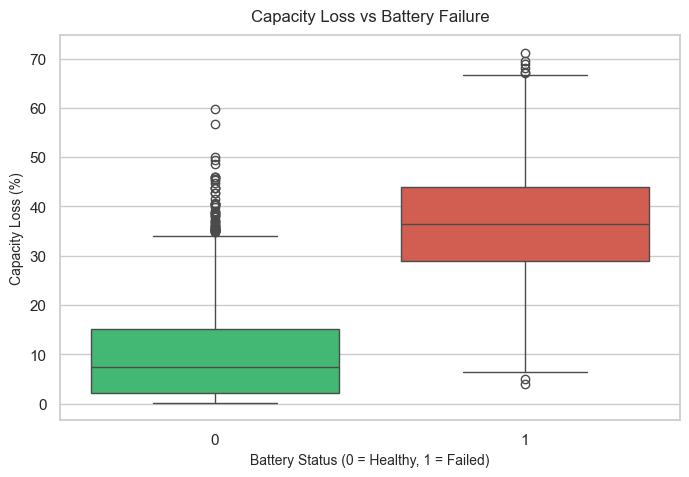

In [27]:
# Compare capacity_loss_percent across healthy (0) and failed (1) batteries
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="battery_failure",
    y="capacity_loss_percent",
    data=df,
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Capacity Loss vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Capacity Loss (%)", fontsize=10)
plt.show()

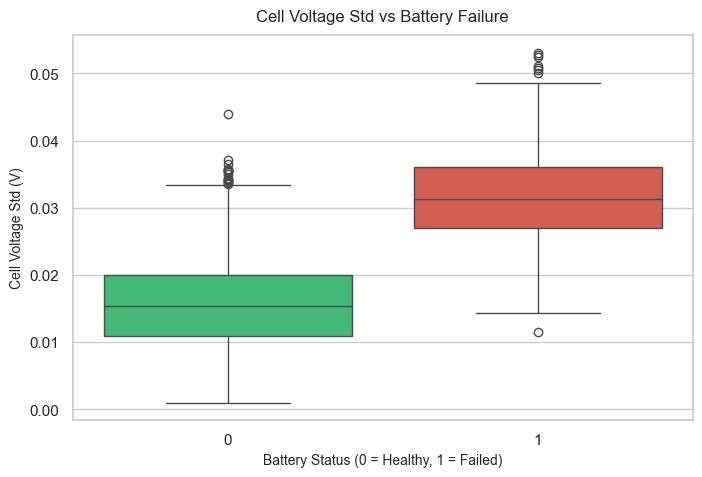

In [28]:
# Compare cell_voltage_std across healthy (0) and failed (1) batteries
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="battery_failure",
    y="cell_voltage_std",
    data=df,
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Cell Voltage Std vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Cell Voltage Std (V)", fontsize=10)
plt.show()

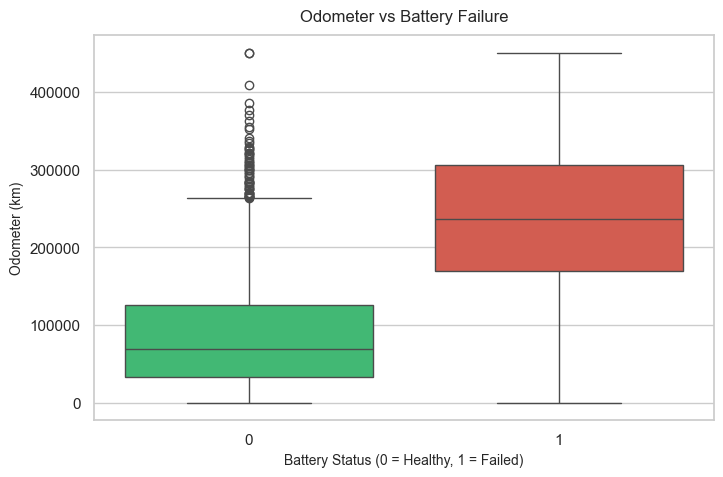

In [29]:
# Compare odometer_km across healthy (0) and failed (1) batteries
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="battery_failure",
    y="odometer_km",
    data=df,
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Odometer vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Odometer (km)", fontsize=10)
plt.show()

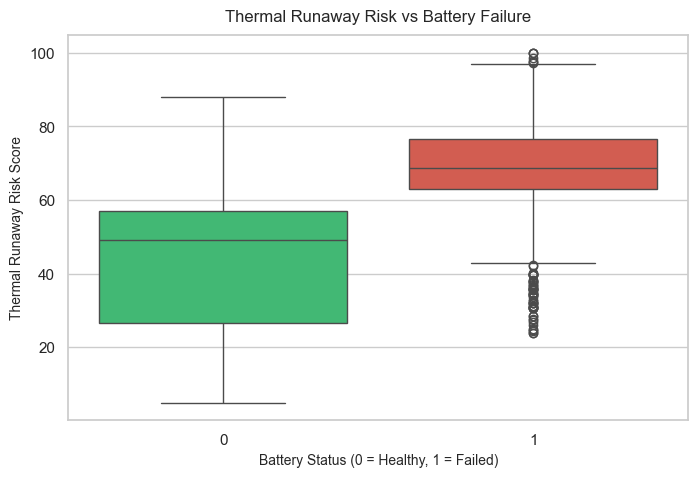

In [30]:
# Compare thermal_runaway_risk across healthy (0) and failed (1) batteries
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="battery_failure",
    y="thermal_runaway_risk",
    data=df,
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Thermal Runaway Risk vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Thermal Runaway Risk Score", fontsize=10)
plt.show()

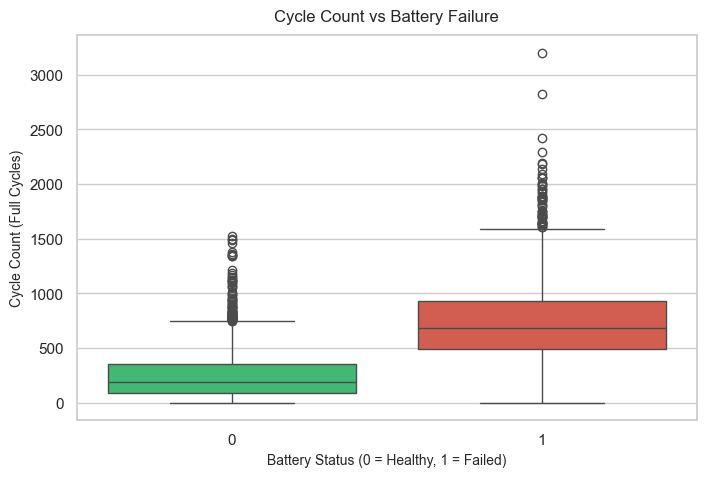

In [31]:
# Compare cycle_count across healthy (0) and failed (1) batteries
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="battery_failure",
    y="cycle_count",
    data=df,
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Cycle Count vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Cycle Count (Full Cycles)", fontsize=10)
plt.show()

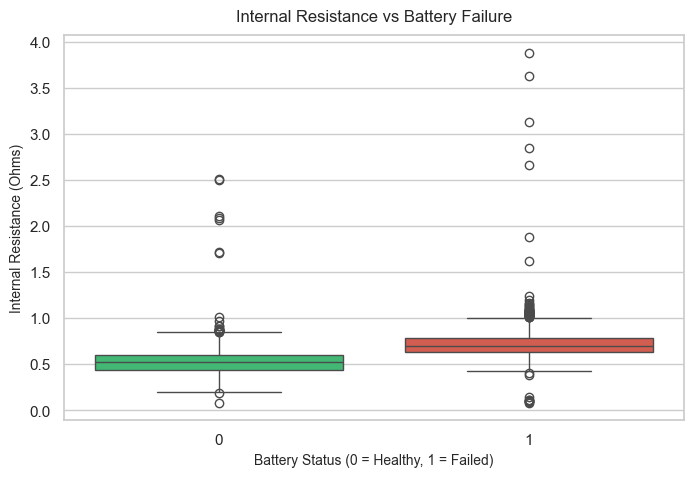

In [32]:
# Compare internal_resistance across healthy (0) and failed (1) batteries
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="battery_failure",
    y="internal_resistance",
    data=df,
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Internal Resistance vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Internal Resistance (Ohms)", fontsize=10)
plt.show()

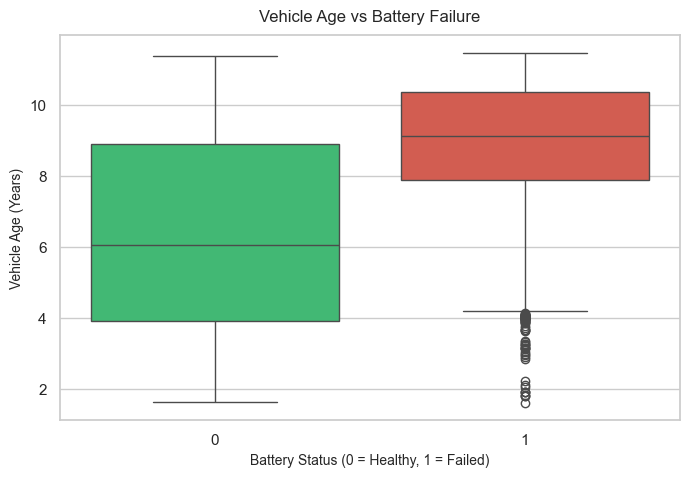

In [33]:
# Compare vehicle_age_years across healthy (0) and failed (1) batteries
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="battery_failure",
    y="vehicle_age_years",
    data=df,
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Vehicle Age vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Vehicle Age (Years)", fontsize=10)
plt.show()

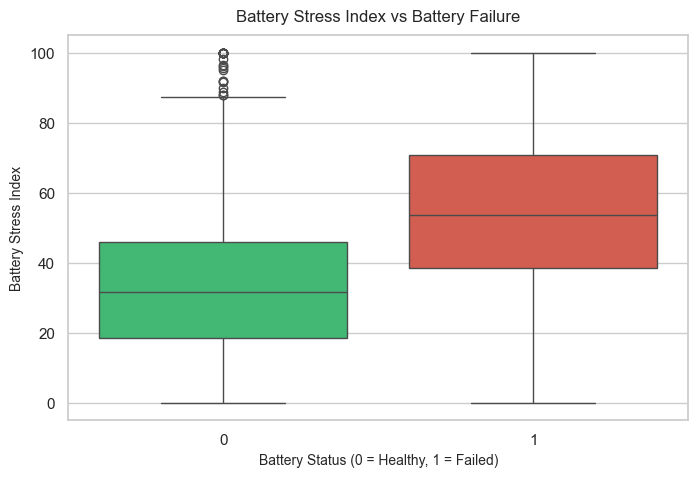

In [34]:
# Compare battery_stress_index across healthy (0) and failed (1) batteries
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="battery_failure",
    y="battery_stress_index",
    data=df,
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Battery Stress Index vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Battery Stress Index", fontsize=10)
plt.show()

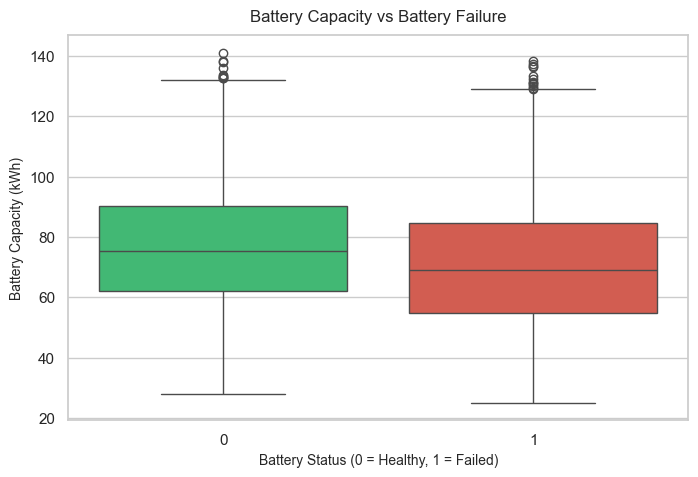

In [35]:
# Compare battery_capacity_kwh across healthy (0) and failed (1) batteries
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="battery_failure",
    y="battery_capacity_kwh",
    data=df,
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Battery Capacity vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Battery Capacity (kWh)", fontsize=10)
plt.show()

### Key Observations from Bivariate Comparisons
* **Failed batteries** exhibit significantly higher capacity loss (median ~37% vs ~10%), higher cell voltage standard deviation (cell imbalance), higher cycle counts, higher odometer mileage, and elevated thermal runaway risk scores.
* **Vehicle Age**: Older vehicles display higher failure proportions.
* **Note**: These plots illustrate statistical associations present in the dataset.

---

## 10. Categorical Feature Analysis

### What we are doing
We analyze the 3 important categorical features: `battery_chemistry`, `vehicle_brand`, and `vehicle_type` using count plots and cross-tabulations.

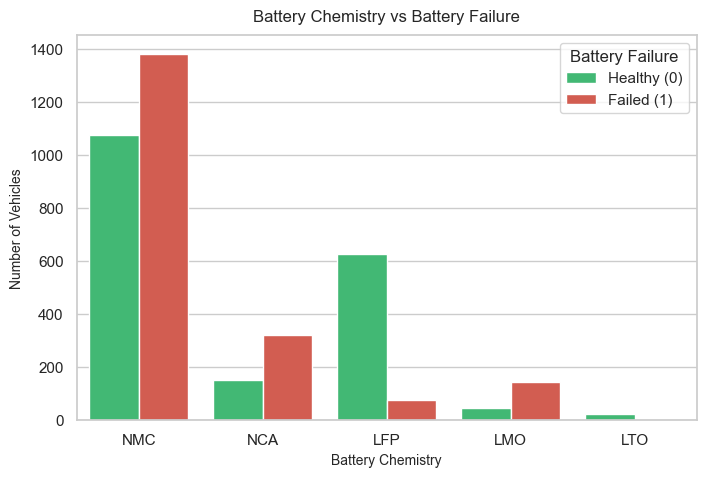

,Healthy (%),Failed (%)
battery_chemistry,,
LMO,24.74,75.26
NCA,32.07,67.93
NMC,43.78,56.22
LFP,89.29,10.71
LTO,100.00,0.00


In [36]:
# 1. Battery Chemistry vs Battery Failure
plt.figure(figsize=(8, 5))
sns.countplot(x="battery_chemistry", hue="battery_failure", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Battery Chemistry vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Chemistry", fontsize=10)
plt.ylabel("Number of Vehicles", fontsize=10)
plt.legend(title="Battery Failure", labels=["Healthy (0)", "Failed (1)"])
plt.show()

# Crosstab percentage table
chem_crosstab = pd.crosstab(df["battery_chemistry"], df["battery_failure"], normalize="index") * 100
chem_crosstab.columns = ["Healthy (%)", "Failed (%)"]
chem_crosstab.round(2).sort_values(by="Failed (%)", ascending=False)

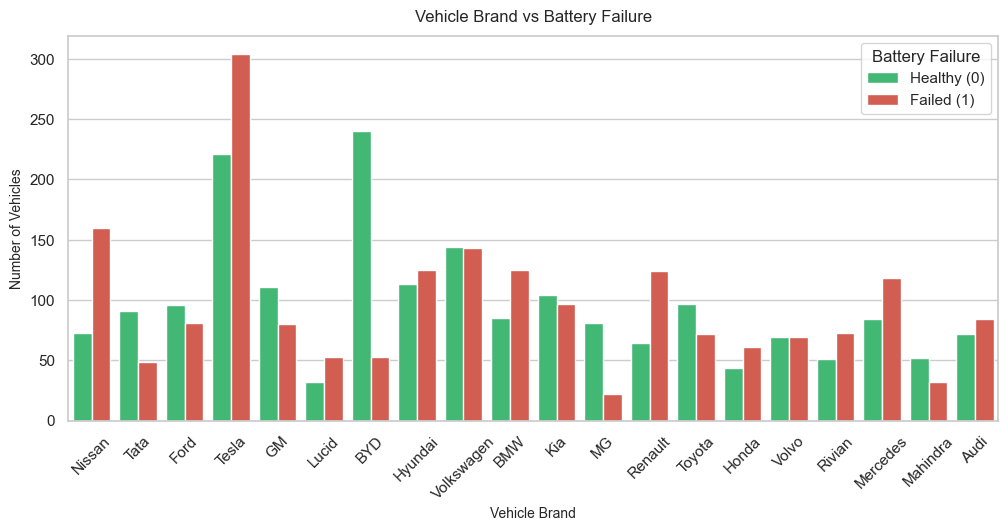

,Healthy (%),Failed (%)
vehicle_brand,,
Nissan,31.33,68.67
Renault,34.04,65.96
Lucid,37.65,62.35
BMW,40.48,59.52
Rivian,41.13,58.87
Mercedes,41.58,58.42
Honda,41.90,58.10
Tesla,42.10,57.90
Audi,46.15,53.85


In [37]:
# 2. Vehicle Brand vs Battery Failure
plt.figure(figsize=(12, 5))
sns.countplot(x="vehicle_brand", hue="battery_failure", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Vehicle Brand vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Vehicle Brand", fontsize=10)
plt.ylabel("Number of Vehicles", fontsize=10)
plt.xticks(rotation=45)
plt.legend(title="Battery Failure", labels=["Healthy (0)", "Failed (1)"])
plt.show()

# Crosstab percentage table
brand_crosstab = pd.crosstab(df["vehicle_brand"], df["battery_failure"], normalize="index") * 100
brand_crosstab.columns = ["Healthy (%)", "Failed (%)"]
brand_crosstab.round(2).sort_values(by="Failed (%)", ascending=False)

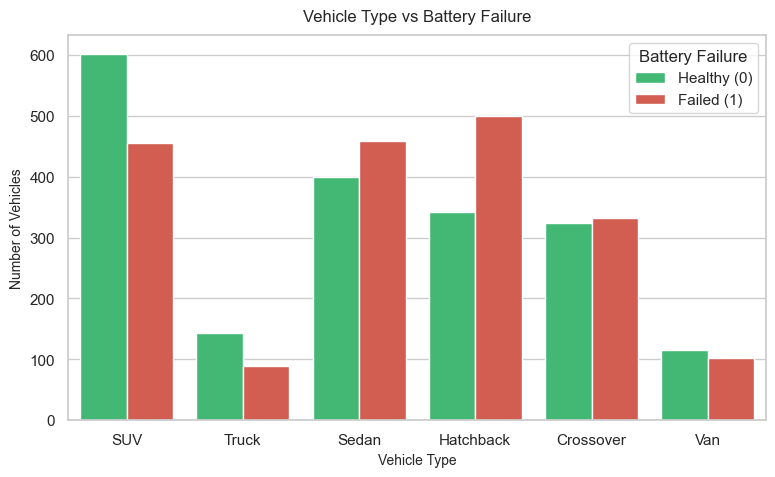

,Healthy (%),Failed (%)
vehicle_type,,
Hatchback,40.67,59.33
Sedan,46.57,53.43
Crossover,49.39,50.61
Van,52.97,47.03
SUV,56.90,43.10
Truck,61.80,38.20


In [38]:
# 3. Vehicle Type vs Battery Failure
plt.figure(figsize=(9, 5))
sns.countplot(x="vehicle_type", hue="battery_failure", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Vehicle Type vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Vehicle Type", fontsize=10)
plt.ylabel("Number of Vehicles", fontsize=10)
plt.legend(title="Battery Failure", labels=["Healthy (0)", "Failed (1)"])
plt.show()

# Crosstab percentage table
type_crosstab = pd.crosstab(df["vehicle_type"], df["battery_failure"], normalize="index") * 100
type_crosstab.columns = ["Healthy (%)", "Failed (%)"]
type_crosstab.round(2).sort_values(by="Failed (%)", ascending=False)

---

## 11. Analyze Excluded Categorical Feature: `drive_type`

### What we are doing
We analyze `drive_type` (FWD, AWD, RWD) and verify why it is excluded.

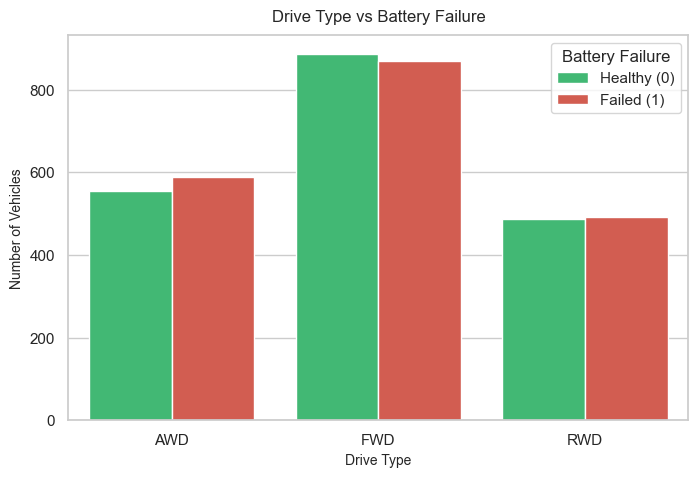

,Healthy (%),Failed (%)
drive_type,,
AWD,48.47,51.53
FWD,50.48,49.52
RWD,49.74,50.26


In [39]:
# Count plot and crosstab of drive_type vs battery_failure
plt.figure(figsize=(8, 5))
sns.countplot(x="drive_type", hue="battery_failure", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Drive Type vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Drive Type", fontsize=10)
plt.ylabel("Number of Vehicles", fontsize=10)
plt.legend(title="Battery Failure", labels=["Healthy (0)", "Failed (1)"])
plt.show()

drive_crosstab = pd.crosstab(df["drive_type"], df["battery_failure"], normalize="index") * 100
drive_crosstab.columns = ["Healthy (%)", "Failed (%)"]
drive_crosstab.round(2)

### Why `drive_type` is Excluded
Failure rates are practically identical (~50%) across AWD (51.5%), FWD (49.5%), and RWD (50.3%). Drive layout provides negligible discriminative signal for battery failure.

---

## 12. Analyze Excluded Numerical Feature: `depth_of_discharge`

### What we are doing
We inspect the distribution and correlation of `depth_of_discharge`.

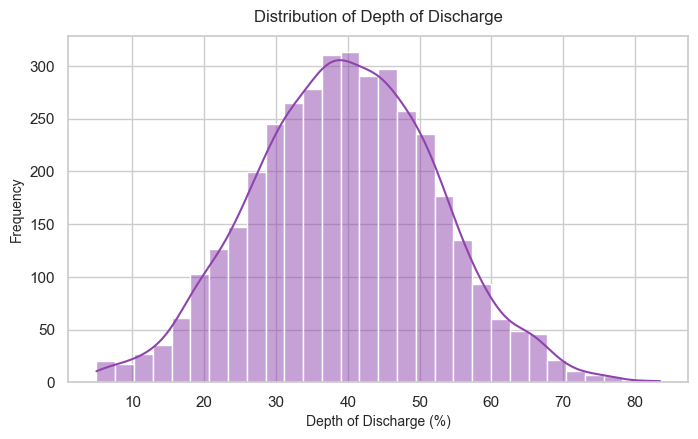

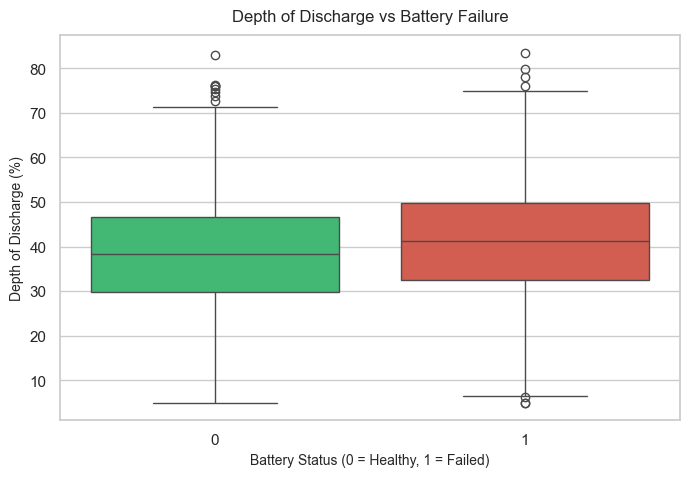

Depth of Discharge Summary Statistics:
count    3833.00
mean       39.67
std        12.61
min         5.00
25%        30.98
50%        39.67
75%        48.34
max        83.49
Name: depth_of_discharge, dtype: float64

Correlation with Battery Failure:
0.1158


In [40]:
# Distribution, boxplot, and target comparison for depth_of_discharge
plt.figure(figsize=(8, 4.5))
sns.histplot(df["depth_of_discharge"].dropna(), kde=True, color="#8e44ad", bins=30)
plt.title("Distribution of Depth of Discharge", fontsize=12, pad=10)
plt.xlabel("Depth of Discharge (%)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="battery_failure", y="depth_of_discharge", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Depth of Discharge vs Battery Failure", fontsize=12, pad=10)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Depth of Discharge (%)", fontsize=10)
plt.show()

print("Depth of Discharge Summary Statistics:")
print(df["depth_of_discharge"].describe().round(2))
print("\nCorrelation with Battery Failure:")
print(df[["depth_of_discharge", "battery_failure"]].corr().iloc[0, 1].round(4))

### Why `depth_of_discharge` is Excluded
Both healthy and failed batteries share overlapping medians (~39.7%) and very low correlation ($r \approx 0.116$). Its operational information is already captured more directly by `cycle_count` and `capacity_loss_percent`.

---

## 13. Correlation Analysis & Multicollinearity Heatmap

### What we are doing
We compute the Pearson correlation matrix across **all 12 numerical features** in the dataset.
The resulting heatmap provides a comprehensive view of inter-feature dependencies, highlighting multicollinear feature pairs (such as `manufacturing_year` with `vehicle_age_years`, and `daily_distance` with `odometer_km` & `cycle_count`).

In [41]:
# Calculate Pearson correlation matrix for all 12 numerical features
correlation_matrix = df[all_numerical_features].corr()
correlation_matrix.round(4)

,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge
cycle_count,1.0000,0.8600,0.5215,0.8217,0.7499,0.5820,0.4247,0.2254,0.7154,-0.5163,-0.4024,0.0707
odometer_km,0.8600,1.0000,0.5990,0.7913,0.7392,0.5331,0.4458,0.2624,0.8393,-0.5953,-0.0224,0.0772
vehicle_age_years,0.5215,0.5990,1.0000,0.4934,0.5487,0.3540,0.2954,0.0929,0.1628,-0.9985,-0.0336,0.0178
capacity_loss_percent,0.8217,0.7913,0.4934,1.0000,0.9057,0.6045,0.7404,0.3573,0.6820,-0.4872,-0.2926,0.0713
cell_voltage_std,0.7499,0.7392,0.5487,0.9057,1.0000,0.5498,0.6815,0.3281,0.5883,-0.5427,-0.2419,0.0672
internal_resistance,0.5820,0.5331,0.3540,0.6045,0.5498,1.0000,0.2751,0.3469,0.4533,-0.3496,-0.2132,0.0690
thermal_runaway_risk,0.4247,0.4458,0.2954,0.7404,0.6815,0.2751,1.0000,0.3567,0.3783,-0.2904,-0.1453,0.0401
battery_stress_index,0.2254,0.2624,0.0929,0.3573,0.3281,0.3469,0.3567,1.0000,0.3046,-0.0902,-0.0119,0.5341
daily_distance,0.7154,0.8393,0.1628,0.6820,0.5883,0.4533,0.3783,0.3046,1.0000,-0.1567,-0.0127,0.0975
manufacturing_year,-0.5163,-0.5953,-0.9985,-0.4872,-0.5427,-0.3496,-0.2904,-0.0902,-0.1567,1.0000,0.0347,-0.0173


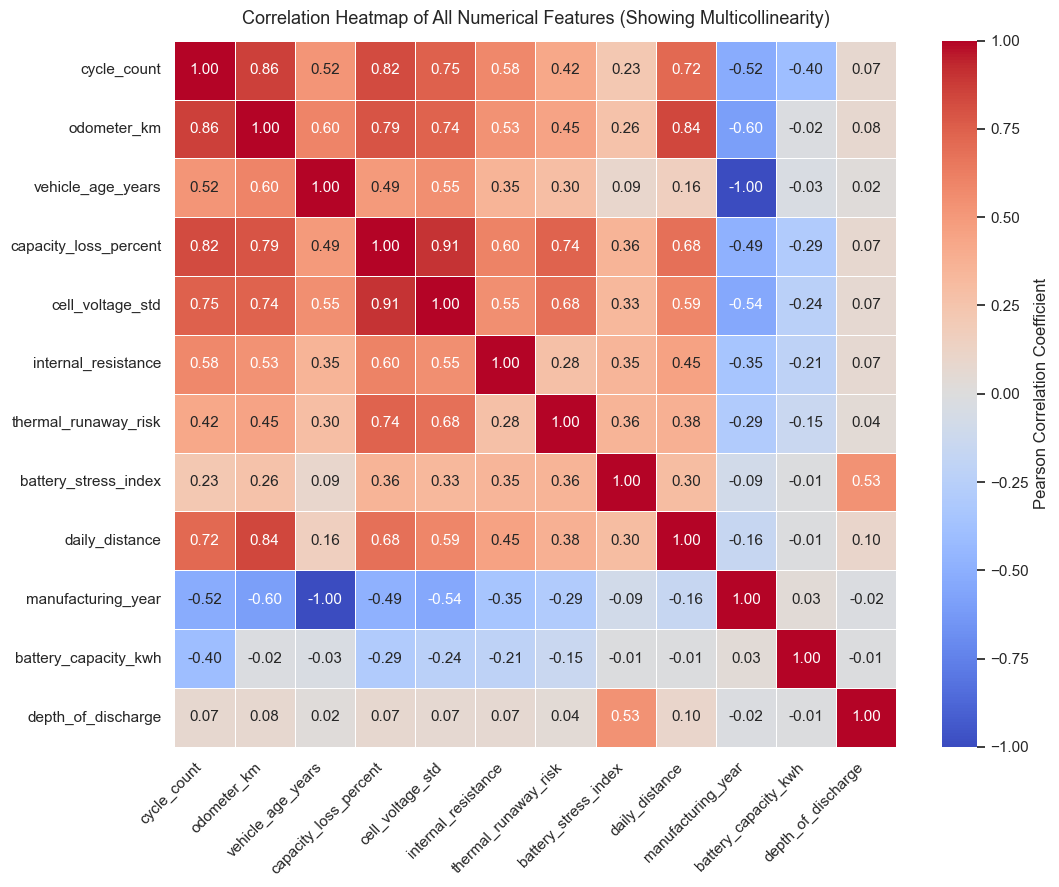

In [42]:
# Plot annotated correlation heatmap showing all numerical features and their multicollinearity
plt.figure(figsize=(11, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient"}
)
plt.title("Correlation Heatmap of All Numerical Features (Showing Multicollinearity)", fontsize=13, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
# Calculate correlation of each numerical feature with the target (battery_failure)
target_corr = df[all_numerical_features + ["battery_failure"]].corr()["battery_failure"]
target_corr_sorted = target_corr.sort_values(ascending=False)

print("Correlation of All Numerical Features with Battery Failure (Signed):")
print(target_corr_sorted.round(4))

# Ranking based on absolute correlation magnitude
abs_target_corr = target_corr.drop("battery_failure").abs().sort_values(ascending=False)

corr_ranking_df = pd.DataFrame({
    "Numerical Feature": abs_target_corr.index,
    "Signed Correlation": target_corr[abs_target_corr.index].values.round(4),
    "Absolute Correlation": abs_target_corr.values.round(4)
})

corr_ranking_df

Correlation of All Numerical Features with Battery Failure (Signed):
battery_failure          1.0000
capacity_loss_percent    0.7892
cell_voltage_std         0.7685
odometer_km              0.6611
thermal_runaway_risk     0.6450
cycle_count              0.6205
daily_distance           0.5444
internal_resistance      0.4880
vehicle_age_years        0.4632
battery_stress_index     0.4506
depth_of_discharge       0.1158
battery_capacity_kwh    -0.1376
manufacturing_year      -0.4652
Name: battery_failure, dtype: float64


,Numerical Feature,Signed Correlation,Absolute Correlation
0,capacity_loss_percent,0.7892,0.7892
1,cell_voltage_std,0.7685,0.7685
2,odometer_km,0.6611,0.6611
3,thermal_runaway_risk,0.6450,0.6450
4,cycle_count,0.6205,0.6205
5,daily_distance,0.5444,0.5444
6,internal_resistance,0.4880,0.4880
7,manufacturing_year,-0.4652,0.4652
8,vehicle_age_years,0.4632,0.4632
9,battery_stress_index,0.4506,0.4506


---

## 14. Check Multicollinearity

### What we are doing
We scan all pairs of numerical features to identify highly correlated pairs exceeding a threshold of $|r| > 0.70$.

In [44]:
# Identify pairs of numerical features with absolute correlation > 0.70
high_corr_pairs = []

for i in range(len(all_numerical_features)):
    for j in range(i + 1, len(all_numerical_features)):
        f1 = all_numerical_features[i]
        f2 = all_numerical_features[j]
        c_val = correlation_matrix.loc[f1, f2]
        if abs(c_val) > 0.70:
            high_corr_pairs.append({
                "Feature 1": f1,
                "Feature 2": f2,
                "Correlation": round(c_val, 4),
                "Absolute Correlation": round(abs(c_val), 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
high_corr_df = high_corr_df.sort_values(by="Absolute Correlation", ascending=False).reset_index(drop=True)
high_corr_df

,Feature 1,Feature 2,Correlation,Absolute Correlation
0,vehicle_age_years,manufacturing_year,-0.9985,0.9985
1,capacity_loss_percent,cell_voltage_std,0.9057,0.9057
2,cycle_count,odometer_km,0.8600,0.8600
3,odometer_km,daily_distance,0.8393,0.8393
4,cycle_count,capacity_loss_percent,0.8217,0.8217
5,odometer_km,capacity_loss_percent,0.7913,0.7913
6,cycle_count,cell_voltage_std,0.7499,0.7499
7,capacity_loss_percent,thermal_runaway_risk,0.7404,0.7404
8,odometer_km,cell_voltage_std,0.7392,0.7392
9,cycle_count,daily_distance,0.7154,0.7154


---

## 15. Feature Removal Based on Multicollinearity

Two features were removed from the final feature set based on the multicollinearity and correlation analysis:

### 1. `manufacturing_year`

`manufacturing_year` was removed because it has an almost perfect negative correlation with `vehicle_age_years` (**r = -0.9985 ≈ -1.00**).

These two features contain virtually identical information because vehicle age is a direct linear reflection of manufacturing year. Keeping both introduces severe multicollinearity, leading to unstable coefficient estimation in linear and distance-based models.

Therefore, `vehicle_age_years` was retained because it directly represents operational aging duration and is more intuitive to interpret.

### 2. `daily_distance`

`daily_distance` was removed because it exhibits strong positive correlation with other vehicle usage features:

* `odometer_km` (**r = 0.8393**)
* `cycle_count` (**r = 0.7154**)

These features provide overlapping information about cumulative vehicle usage throughput.

Therefore, `daily_distance` was removed while retaining `odometer_km` and `cycle_count`, which provide more direct measurements of cumulative vehicle mileage and battery charge/discharge cycles.

### Final Pruning Decision

The two collinear features were removed to:
* Eliminate redundant information
* Prevent multicollinearity distortions
* Simplify the feature space
* Improve model interpretability

The remaining 9 numerical features provide complementary information about battery degradation, cell electrical state, vehicle usage, and pack capacity.

In [45]:
# Define the 9 selected numerical features after removing multicollinear features
numerical_features = [
    "capacity_loss_percent",
    "cell_voltage_std",
    "odometer_km",
    "thermal_runaway_risk",
    "cycle_count",
    "internal_resistance",
    "vehicle_age_years",
    "battery_stress_index",
    "battery_capacity_kwh"
]

print(f"Selected {len(numerical_features)} numerical features after multicollinearity pruning:")
for idx, f in enumerate(numerical_features, 1):
    print(f"{idx}. {f}")

Selected 9 numerical features after multicollinearity pruning:
1. capacity_loss_percent
2. cell_voltage_std
3. odometer_km
4. thermal_runaway_risk
5. cycle_count
6. internal_resistance
7. vehicle_age_years
8. battery_stress_index
9. battery_capacity_kwh


---

## 16. Key EDA Findings

### 1. Dataset Dimensions & Structure
* **Total Rows**: 4,000 observations.
* **Total Features**: 17 attributes in raw dataset (12 numerical predictors + 4 categorical predictors + 1 target).

### 2. Data Quality
* **Missing Values**: Low proportions (3.0% to 5.1%) across features. `battery_failure` has 0 missing values.
* **Duplicates**: 0 duplicate rows.

### 3. Target Variable Balance
* Balanced distribution (50.0% Healthy / 50.0% Failed).

### 4. Selected Features After Multicollinearity Pruning
* **9 Numerical Features**: `capacity_loss_percent`, `cell_voltage_std`, `odometer_km`, `thermal_runaway_risk`, `cycle_count`, `internal_resistance`, `vehicle_age_years`, `battery_stress_index`, `battery_capacity_kwh`.
* **3 Categorical Features**: `battery_chemistry`, `vehicle_brand`, `vehicle_type`.
* **Pruned Features**: `manufacturing_year` (collinear with `vehicle_age_years`), `daily_distance` (redundant with `odometer_km` & `cycle_count`), `drive_type` (zero association), `depth_of_discharge` (low correlation / identical distributions).

---

## 17. Final Feature Set for Machine Learning

### 9 Selected Numerical Features:
1. `capacity_loss_percent` — Battery capacity fade (%)
2. `cell_voltage_std` — Cell-to-cell voltage standard deviation (V)
3. `odometer_km` — Total vehicle odometer distance (km)
4. `thermal_runaway_risk` — Thermal runaway vulnerability index (0 to 100)
5. `cycle_count` — Cumulative charge/discharge cycle count
6. `internal_resistance` — Battery internal resistance (Ohms)
7. `vehicle_age_years` — Vehicle age in years
8. `battery_stress_index` — Composite operational stress index (0 to 100)
9. `battery_capacity_kwh` — Pack energy capacity (kWh)

### 3 Selected Categorical Features:
1. `battery_chemistry` — Cathode chemistry type (NMC, LFP, NCA, LMO, LTO)
2. `vehicle_brand` — Automotive manufacturer
3. `vehicle_type` — Vehicle body form factor (SUV, Sedan, Hatchback, Crossover, Truck, Van)

### 1 Target Variable:
* `battery_failure` — Binary target (0 = Healthy, 1 = Failed)

$$\mathbf{12	ext{ Input Features}} + \mathbf{1	ext{ Target Variable}} = \mathbf{13	ext{ Selected Columns}}$$

---

# PART 2: MACHINE LEARNING MODELING (NO PIPELINES)

---

## 18. Machine Learning Introduction & Workflow

### Explicit, Step-by-Step ML Implementation (NO PIPELINES)
Training-only preprocessing was used. Imputation and scaling parameters were learned exclusively from the training data. Feature selection was guided by exploratory analysis before model training.

Every step is implemented explicitly and step-by-step:
1. **Train-Test Split** (80% Train / 20% Test, Stratified)
2. **Handle Missing Values** (Manual median/mode imputation using training statistics)
3. **Encode Categorical Variables** (One-Hot Encoding with `pd.get_dummies`)
4. **Scale Numerical Variables** (StandardScaler manually fitted on train, transformed on test)
5. **Train 6 Classification Models Explicitly**:
   - Logistic Regression
   - K-Nearest Neighbors (KNN)
   - Decision Tree Classifier
   - Random Forest Classifier
   - Support Vector Machine (SVM)
   - Gradient Boosting Classifier
6. **Evaluate Baseline Models** (Accuracy, Precision, Recall, F1 Score, ROC-AUC)
7. **Confusion Matrix & Classification Report Analysis**
8. **Hyperparameter Tuning with GridSearchCV** (on `X_train`, `y_train` directly)
9. **Tuned Model Comparison & Selection**
10. **ROC Curves & Feature Interpretation**
11. **Save Final Model & Scaler**

---

## 19. Import Machine Learning Libraries

### What we are doing
We import only the essential Scikit-Learn modules needed for splitting, scaling, modeling, metric evaluation, grid search, and saving.

In [46]:
# Import core and Machine Learning libraries (NO Pipeline, NO ColumnTransformer)
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Import 6 classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

import joblib

# Set plot styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All data science & machine learning libraries imported successfully!")

All data science & machine learning libraries imported successfully!


---

## 20. Select Features (X) and Target (y)

### What we are doing
We define the exact 12 selected features (9 numerical and 3 categorical) and separate our feature matrix `X` from the target vector `y`.

In [47]:
# Load dataset and define feature lists (9 numerical + 3 categorical = 12 input features)
df = pd.read_csv("ev_battery_health_subset(3).csv")

numerical_features = [
    "capacity_loss_percent",
    "cell_voltage_std",
    "odometer_km",
    "thermal_runaway_risk",
    "cycle_count",
    "internal_resistance",
    "vehicle_age_years",
    "battery_stress_index",
    "battery_capacity_kwh"
]

categorical_features = [
    "battery_chemistry",
    "vehicle_brand",
    "vehicle_type"
]

feature_columns = numerical_features + categorical_features

# Create X and y
X = df[feature_columns].copy()
y = df["battery_failure"].copy()

print(f"Features shape (X): {X.shape} (12 features)")
print(f"Target shape   (y): {y.shape}")

Features shape (X): (4000, 12) (12 features)
Target shape   (y): (4000,)


---

## 21. Train-Test Split

### What we are doing
We split `X` and `y` into **80% training data** (`X_train`, `y_train`) and **20% testing data** (`X_test`, `y_test`).

In [48]:
# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_test distribution :\n{y_test.value_counts()}")

X_train shape: (3200, 12)
X_test shape : (800, 12)
y_train distribution:
battery_failure
1    1600
0    1600
Name: count, dtype: int64
y_test distribution :
battery_failure
1    400
0    400
Name: count, dtype: int64


---

## 22. Handle Missing Values Manually

### What we are doing
We handle missing values step-by-step:
* **Numerical Features**: Fill missing values with the **training median**.
* **Categorical Features**: Fill missing values with the **training mode**.

In [49]:
# Check missing values before imputation
print("Missing values in X_train before imputation:")
print(X_train.isnull().sum())

# 1. Fill missing numerical values with training median
for column in numerical_features:
    median_value = X_train[column].median()
    X_train[column] = X_train[column].fillna(median_value)
    X_test[column] = X_test[column].fillna(median_value)

# 2. Fill missing categorical values with training mode
for column in categorical_features:
    mode_value = X_train[column].mode()[0]
    X_train[column] = X_train[column].fillna(mode_value)
    X_test[column] = X_test[column].fillna(mode_value)

print("\nMissing values in X_train after imputation:", X_train.isnull().sum().sum())
print("Missing values in X_test after imputation :", X_test.isnull().sum().sum())

Missing values in X_train before imputation:
capacity_loss_percent    166
cell_voltage_std         138
odometer_km              134
thermal_runaway_risk     107
cycle_count              125
internal_resistance      133
vehicle_age_years        139
battery_stress_index     122
battery_capacity_kwh     136
battery_chemistry        128
vehicle_brand            124
vehicle_type             106
dtype: int64

Missing values in X_train after imputation: 0
Missing values in X_test after imputation : 0


---

## 23. Encode Categorical Variables with `pd.get_dummies`

### What we are doing
We convert categorical features (`battery_chemistry`, `vehicle_brand`, `vehicle_type`) into numeric dummy variables.

In [50]:
# Perform One-Hot Encoding using pandas get_dummies
X_train = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# Align columns so X_train and X_test have identical columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(f"X_train shape after encoding: {X_train.shape}")
print(f"X_test shape after encoding : {X_test.shape}")

X_train shape after encoding: (3200, 37)
X_test shape after encoding : (800, 37)


---

## 24. Scale Numerical Features Manually

### What we are doing
We scale the 9 numerical features using `StandardScaler` (mean = 0, std = 1).

In [51]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Numerical features scaled successfully!")
print(f"Final preprocessed X_train shape: {X_train.shape}")
print(f"Final preprocessed X_test shape : {X_test.shape}")
X_train.head()

Numerical features scaled successfully!
Final preprocessed X_train shape: (3200, 37)
Final preprocessed X_test shape : (800, 37)


,capacity_loss_percent,cell_voltage_std,odometer_km,thermal_runaway_risk,cycle_count,internal_resistance,vehicle_age_years,battery_stress_index,battery_capacity_kwh,battery_chemistry_LMO,...,vehicle_brand_Tata,vehicle_brand_Tesla,vehicle_brand_Toyota,vehicle_brand_Volkswagen,vehicle_brand_Volvo,vehicle_type_Hatchback,vehicle_type_SUV,vehicle_type_Sedan,vehicle_type_Truck,vehicle_type_Van
3423,1.367861,1.127463,1.178559,1.806354,0.654547,-0.015664,0.831951,-0.435976,0.285823,False,...,False,True,False,False,False,False,False,False,False,False
760,-0.818476,-0.114859,-0.881942,-2.081484,-0.544016,0.311178,-0.541327,-0.494437,-1.268055,False,...,False,True,False,False,False,True,False,False,False,False
1032,0.151609,0.282162,-0.329869,1.552800,-0.302730,0.441813,0.086562,0.085992,-0.064128,False,...,False,False,False,False,False,False,True,False,False,False
3676,1.208004,1.405880,-0.404038,0.073731,-0.334202,1.047717,-1.308748,1.242673,-0.489901,True,...,False,True,False,False,False,False,False,True,False,False
2879,-0.918767,-0.654606,-1.184097,-0.000223,-1.081665,-1.034823,-1.705309,-0.907836,-0.472890,False,...,False,False,False,False,False,False,False,True,False,False


---

## 25. Train 6 Classification Models

### What we are doing
We train 6 distinct classification models explicitly:
1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree Classifier**
4. **Random Forest Classifier**
5. **Support Vector Machine (SVM)**
6. **Gradient Boosting Classifier**

In [52]:
# 1. Logistic Regression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# 2. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# 3. Decision Tree
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# 4. Random Forest
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# 5. Support Vector Machine (SVM)
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# 6. Gradient Boosting
gradient_boosting_model = GradientBoostingClassifier(random_state=42)
gradient_boosting_model.fit(X_train, y_train)

print("All 6 classification models trained successfully!")

All 6 classification models trained successfully!


---

## 26. Evaluate Baseline Models

### What we are doing
We compute Accuracy, Precision, Recall, F1 Score, and ROC-AUC on `X_test` for every model.

In [53]:
# Evaluate Model 1: Logistic Regression
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Evaluate Model 2: KNN
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

# Evaluate Model 3: Decision Tree
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

# Evaluate Model 4: Random Forest
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Evaluate Model 5: SVM
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

# Evaluate Model 6: Gradient Boosting
y_pred_gb = gradient_boosting_model.predict(X_test)
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]
acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Evaluation metrics computed for all 6 models.")

  File "C:\Users\sumer\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\sumer\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sumer\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                

Evaluation metrics computed for all 6 models.


---

## 27. Baseline Model Comparison Table

### What we are doing
We compile the evaluation scores into a single summary DataFrame and sort by **F1 Score**.

In [54]:
# Create Baseline Model Comparison Table
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "Gradient Boosting"
    ],
    "Accuracy": [acc_lr, acc_knn, acc_dt, acc_rf, acc_svm, acc_gb],
    "Precision": [prec_lr, prec_knn, prec_dt, prec_rf, prec_svm, prec_gb],
    "Recall": [rec_lr, rec_knn, rec_dt, rec_rf, rec_svm, rec_gb],
    "F1 Score": [f1_lr, f1_knn, f1_dt, f1_rf, f1_svm, f1_gb],
    "ROC-AUC": [auc_lr, auc_knn, auc_dt, auc_rf, auc_svm, auc_gb]
})

# Display sorted by F1 Score descending
baseline_results.sort_values(by="F1 Score", ascending=False).reset_index(drop=True).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.9288,0.9235,0.9350,0.9292,0.9783
1,Logistic Regression,0.9262,0.9210,0.9325,0.9267,0.9800
2,Random Forest,0.9238,0.9248,0.9225,0.9237,0.9770
3,Support Vector Machine,0.9212,0.9140,0.9300,0.9219,0.9722
4,K-Nearest Neighbors,0.8962,0.9013,0.8900,0.8956,0.9563
5,Decision Tree,0.8788,0.8686,0.8925,0.8804,0.8788


---

## 28. Confusion Matrices & Classification Reports

### Understanding the Confusion Matrix in Battery Health Screening:
* **True Positive (TP)**: Predicted Failure, Actually Failed (Correctly flagged for inspection).
* **True Negative (TN)**: Predicted Healthy, Actually Healthy (Normal operation).
* **False Positive (FP)**: Predicted Failure, Actually Healthy (Unnecessary inspection cost).
* **False Negative (FN)**: Predicted Healthy, **Actually Failed** (Degraded battery remains in service without maintenance).

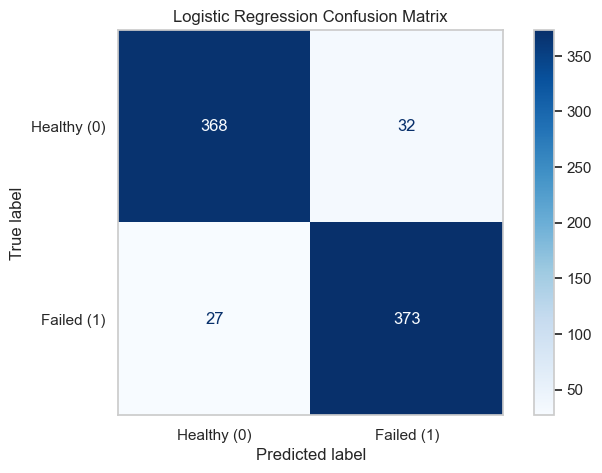

--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

 Healthy (0)       0.93      0.92      0.93       400
  Failed (1)       0.92      0.93      0.93       400

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



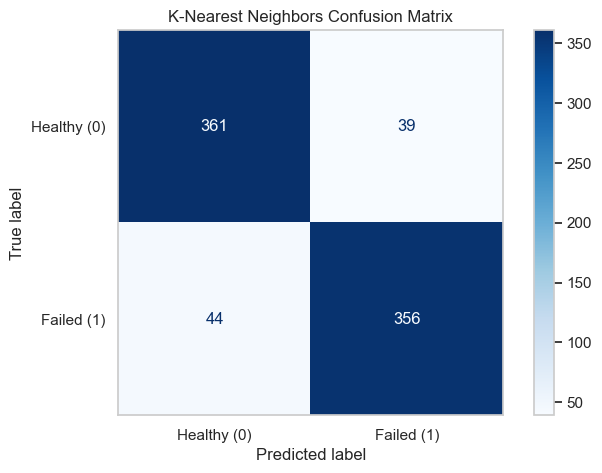

--- Classification Report: K-Nearest Neighbors ---
              precision    recall  f1-score   support

 Healthy (0)       0.89      0.90      0.90       400
  Failed (1)       0.90      0.89      0.90       400

    accuracy                           0.90       800
   macro avg       0.90      0.90      0.90       800
weighted avg       0.90      0.90      0.90       800



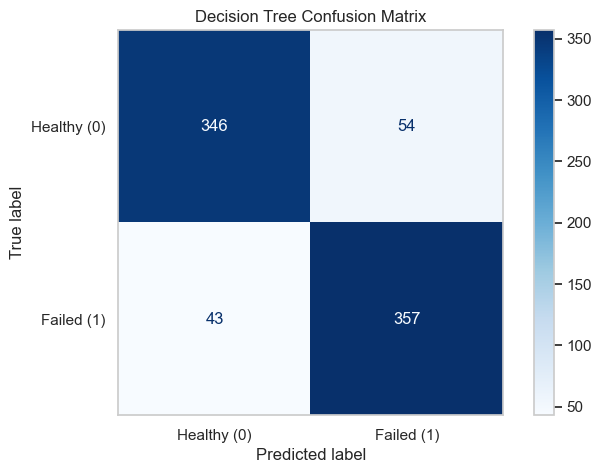

--- Classification Report: Decision Tree ---
              precision    recall  f1-score   support

 Healthy (0)       0.89      0.86      0.88       400
  Failed (1)       0.87      0.89      0.88       400

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.88       800
weighted avg       0.88      0.88      0.88       800



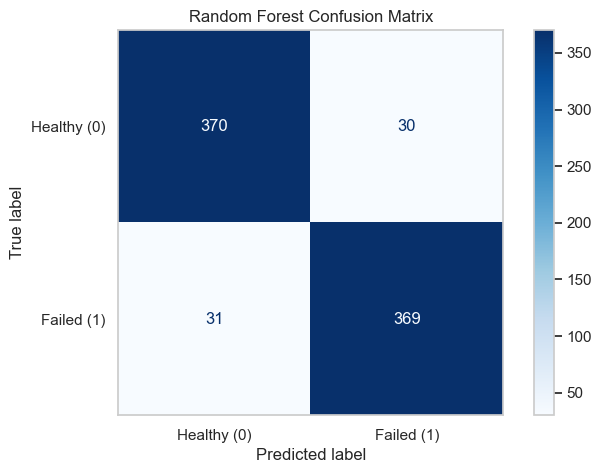

--- Classification Report: Random Forest ---
              precision    recall  f1-score   support

 Healthy (0)       0.92      0.93      0.92       400
  Failed (1)       0.92      0.92      0.92       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



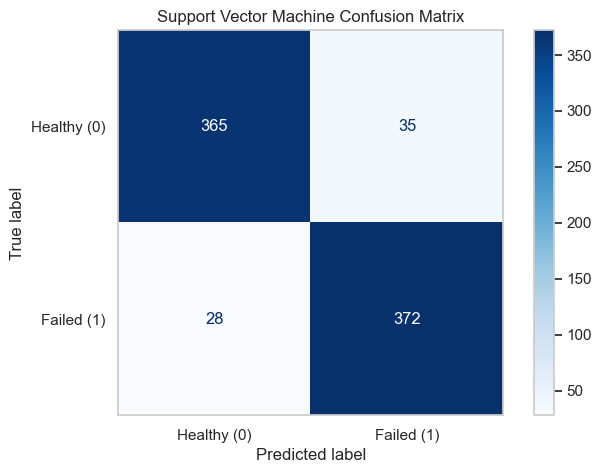

--- Classification Report: Support Vector Machine ---
              precision    recall  f1-score   support

 Healthy (0)       0.93      0.91      0.92       400
  Failed (1)       0.91      0.93      0.92       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



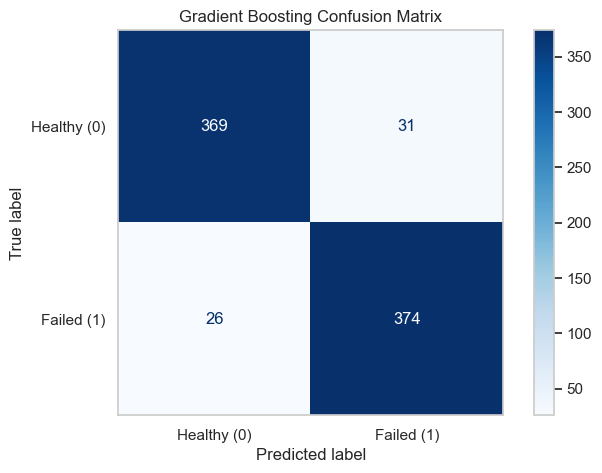

--- Classification Report: Gradient Boosting ---
              precision    recall  f1-score   support

 Healthy (0)       0.93      0.92      0.93       400
  Failed (1)       0.92      0.94      0.93       400

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



In [55]:
# Display Confusion Matrix and Classification Report for each model
models_to_display = [
    ("Logistic Regression", y_pred_lr),
    ("K-Nearest Neighbors", y_pred_knn),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf),
    ("Support Vector Machine", y_pred_svm),
    ("Gradient Boosting", y_pred_gb)
]

for name, y_pred in models_to_display:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy (0)", "Failed (1)"])
    disp.plot(cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.grid(False)
    plt.show()
    
    print(f"--- Classification Report: {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Healthy (0)", "Failed (1)"]))
    print("=" * 60)

---

## 29. Hyperparameter Tuning with GridSearchCV (NO PIPELINES)

### What we are doing
We tune each model separately using `GridSearchCV` on the preprocessed `X_train` and `y_train` directly:
* `cv=5`: 5-fold cross-validation.
* `scoring="f1"`: Optimizes directly for F1-Score.

In [56]:
# 1. Tune Logistic Regression
param_grid_lr = {"C": [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5, scoring="f1")
grid_lr.fit(X_train, y_train)
print("Logistic Regression Best Params:", grid_lr.best_params_, "| Best CV F1:", round(grid_lr.best_score_, 4))

# 2. Tune KNN
param_grid_knn = {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring="f1")
grid_knn.fit(X_train, y_train)
print("KNN Best Params:", grid_knn.best_params_, "| Best CV F1:", round(grid_knn.best_score_, 4))

# 3. Tune Decision Tree
param_grid_dt = {"max_depth": [None, 5, 10, 15, 20], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring="f1")
grid_dt.fit(X_train, y_train)
print("Decision Tree Best Params:", grid_dt.best_params_, "| Best CV F1:", round(grid_dt.best_score_, 4))

# 4. Tune Random Forest
param_grid_rf = {"n_estimators": [100, 200], "max_depth": [None, 10, 20], "min_samples_split": [2, 5]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring="f1")
grid_rf.fit(X_train, y_train)
print("Random Forest Best Params:", grid_rf.best_params_, "| Best CV F1:", round(grid_rf.best_score_, 4))

# 5. Tune SVM
param_grid_svm = {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
grid_svm = GridSearchCV(SVC(probability=True, random_state=42), param_grid_svm, cv=5, scoring="f1")
grid_svm.fit(X_train, y_train)
print("SVM Best Params:", grid_svm.best_params_, "| Best CV F1:", round(grid_svm.best_score_, 4))

# 6. Tune Gradient Boosting
param_grid_gb = {"n_estimators": [50, 100, 150], "learning_rate": [0.01, 0.1, 0.2], "max_depth": [2, 3, 5]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring="f1")
grid_gb.fit(X_train, y_train)
print("Gradient Boosting Best Params:", grid_gb.best_params_, "| Best CV F1:", round(grid_gb.best_score_, 4))

Logistic Regression Best Params: {'C': 0.1} | Best CV F1: 0.9255


KNN Best Params: {'n_neighbors': 11, 'weights': 'distance'} | Best CV F1: 0.9153


Decision Tree Best Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10} | Best CV F1: 0.9072


Random Forest Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100} | Best CV F1: 0.9192


SVM Best Params: {'C': 1, 'kernel': 'linear'} | Best CV F1: 0.9242


Gradient Boosting Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50} | Best CV F1: 0.9227


---

## 30. Evaluate Tuned Models & Final Comparison Table

### What we are doing
We take `best_estimator_` from each grid search and evaluate its performance on the unseen test set (`X_test`, `y_test`).

In [57]:
# Evaluate each tuned model on the test set
tuned_models = {
    "Logistic Regression": grid_lr,
    "K-Nearest Neighbors": grid_knn,
    "Decision Tree": grid_dt,
    "Random Forest": grid_rf,
    "Support Vector Machine": grid_svm,
    "Gradient Boosting": grid_gb
}

tuned_results_data = []

for name, grid in tuned_models.items():
    best_mod = grid.best_estimator_
    y_pred = best_mod.predict(X_test)
    y_prob = best_mod.predict_proba(X_test)[:, 1]
    
    tuned_results_data.append({
        "Model": name,
        "CV F1": round(grid.best_score_, 4),
        "Test Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Test Precision": round(precision_score(y_test, y_pred), 4),
        "Test Recall": round(recall_score(y_test, y_pred), 4),
        "Test F1": round(f1_score(y_test, y_pred), 4),
        "Test ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)
    })

tuned_comparison_table = pd.DataFrame(tuned_results_data)
tuned_comparison_table = tuned_comparison_table.sort_values(by="Test F1", ascending=False).reset_index(drop=True)

print("=== Tuned Models Evaluation Table ===")
tuned_comparison_table

=== Tuned Models Evaluation Table ===


,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Gradient Boosting,0.9227,0.9300,0.9216,0.9400,0.9307,0.9786
1,Logistic Regression,0.9255,0.9300,0.9279,0.9325,0.9302,0.9807
2,Support Vector Machine,0.9242,0.9225,0.9163,0.9300,0.9231,0.9787
3,K-Nearest Neighbors,0.9153,0.9213,0.9080,0.9375,0.9225,0.9683
4,Decision Tree,0.9072,0.9213,0.9223,0.9200,0.9212,0.9594
5,Random Forest,0.9192,0.9187,0.9198,0.9175,0.9186,0.9740


---

## 31. Select Final Best Model

### Multi-Criteria Selection Rationale:
* **Cross-Validation F1**: **Highest mean 5-fold cross-validation F1 score (0.9255)**.
* **Highest Test ROC-AUC**: **0.9807** (outperforming all other models).
* **Balanced Test Metrics**: Test Accuracy = **93.00%**, Precision = **92.79%**, Recall = **93.25%**, Test F1 = **0.9302**.
* **Linear Interpretability & Low Complexity**: Direct coefficient transparency with simple linear dot-product inference.
* **Model**: **Tuned Logistic Regression (`C=0.1`)** is selected as the champion model.

In [58]:
# Select the Best Tuned Model
best_model = grid_lr.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("Selected Final Best Model:")
print(best_model)

Selected Final Best Model:
LogisticRegression(C=0.1, max_iter=1000, random_state=42)


---

## 32. Final Confusion Matrix & Combined ROC Curves

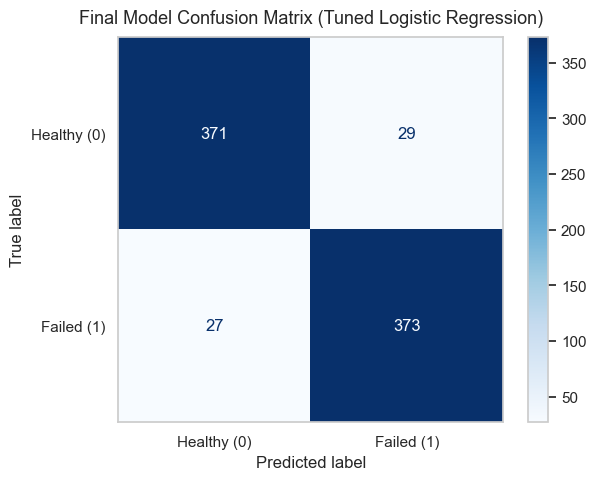

--- Final Model Classification Report ---
              precision    recall  f1-score   support

 Healthy (0)       0.93      0.93      0.93       400
  Failed (1)       0.93      0.93      0.93       400

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



In [59]:
# Plot Confusion Matrix for Final Best Model
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6.5, 5))
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["Healthy (0)", "Failed (1)"])
disp_best.plot(cmap="Blues", ax=plt.gca())
plt.title("Final Model Confusion Matrix (Tuned Logistic Regression)", fontsize=13, pad=10)
plt.grid(False)
plt.show()

print("--- Final Model Classification Report ---")
print(classification_report(y_test, y_pred_best, target_names=["Healthy (0)", "Failed (1)"]))

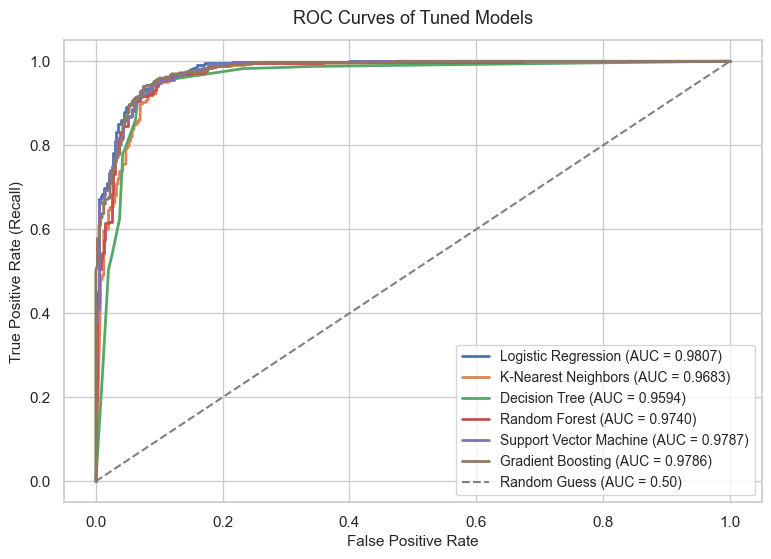

In [60]:
# Plot Combined ROC Curves for all Tuned Models
plt.figure(figsize=(9, 6))

for name, grid in tuned_models.items():
    model = grid.best_estimator_
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1.5, label="Random Guess (AUC = 0.50)")
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate (Recall)", fontsize=11)
plt.title("ROC Curves of Tuned Models", fontsize=13, pad=12)
plt.legend(loc="lower right", fontsize=10)
plt.show()

---

## 33. Top Features by Absolute Logistic Regression Coefficient

### What we are doing
We extract model coefficients from `best_model.coef_[0]`, match them with `X_train.columns`, and identify the top features by absolute Logistic Regression coefficient.

> [!NOTE]
> **Model Interpretation Note**:
> These values represent **parametric model coefficients** ($eta$) indicating the change in log-odds of battery failure per unit standard deviation increase in that feature. They are used for linear model interpretation and are distinct from generic tree-based `feature_importances_`.

=== Top 15 Most Important Features ===
                     Feature  Coefficient  Absolute Importance
0           cell_voltage_std     1.265755             1.265755
1       thermal_runaway_risk     1.168639             1.168639
2       battery_stress_index     1.086009             1.086009
3      capacity_loss_percent     0.892946             0.892946
4          vehicle_age_years     0.507782             0.507782
5                odometer_km     0.458124             0.458124
6                cycle_count     0.438569             0.438569
7           vehicle_type_SUV    -0.259038             0.259038
8     vehicle_type_Hatchback    -0.257966             0.257966
9         vehicle_type_Truck    -0.236483             0.236483
10          vehicle_brand_MG    -0.229612             0.229612
11     vehicle_brand_Hyundai     0.179423             0.179423
12  vehicle_brand_Volkswagen    -0.159907             0.159907
13     battery_chemistry_NCA    -0.146564             0.146564
14          vehi

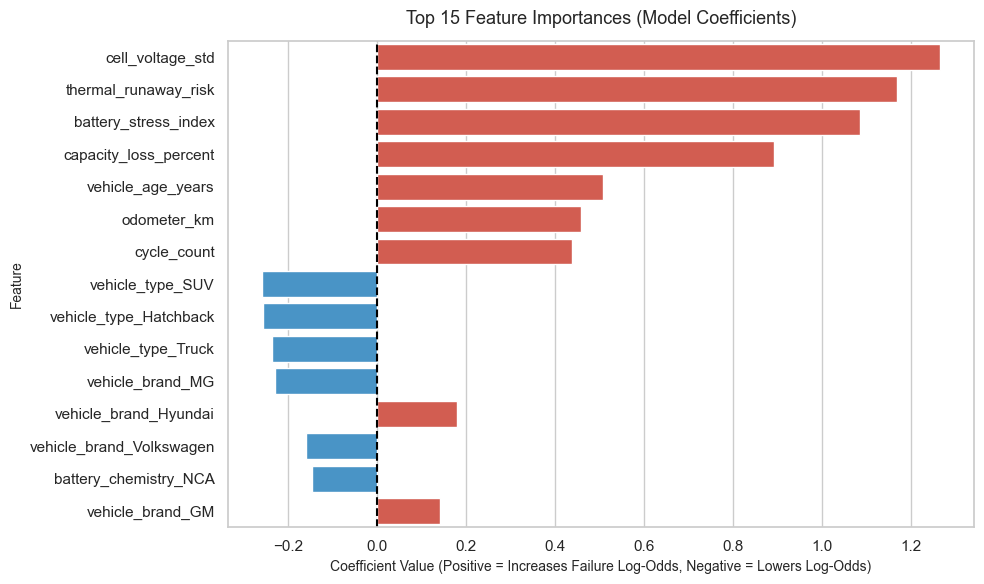

In [61]:
# Extract Feature Coefficients for the Best Model
coefficients = best_model.coef_[0]

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefficients,
    "Absolute Importance": np.abs(coefficients)
}).sort_values(by="Absolute Importance", ascending=False).reset_index(drop=True)

print("=== Top Features by Absolute Logistic Regression Coefficient ===")
print(feature_importance_df.head(15))

# Plot Top 15 Features
top15 = feature_importance_df.head(15)
plt.figure(figsize=(10, 6))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in top15["Coefficient"]]
sns.barplot(x="Coefficient", y="Feature", data=top15, palette=colors)
plt.title("Top Features by Absolute Logistic Regression Coefficient", fontsize=13, pad=12)
plt.xlabel("Coefficient Value (Positive = Increases Failure Log-Odds, Negative = Lowers Log-Odds)", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.axvline(x=0, color="black", linestyle="--")
plt.tight_layout()
plt.show()

---

## 34. Save Best Model and Scaler

### What we are doing
We save the final trained model and the scaler to disk using `joblib`.

### Deployment Note & Preprocessing Limitation
The current implementation saves the trained model and scaler separately. The categorical one-hot encoding procedure is not packaged into the saved model, so deployment would require reproducing the same encoding and feature ordering. A future production implementation could package the complete preprocessing and model together.

In [62]:
# Save the best model and scaler to disk
joblib.dump(best_model, "best_ev_battery_model.pkl")
joblib.dump(scaler, "ev_battery_scaler.pkl")

print("✓ Model saved successfully to 'best_ev_battery_model.pkl'")
print("✓ Scaler saved successfully to 'ev_battery_scaler.pkl'")

# Verification test: Load the model and scaler back and predict on 5 test samples
loaded_model = joblib.load("best_ev_battery_model.pkl")
sample_features = X_test.head(5)
sample_predictions = loaded_model.predict(sample_features)

print("\n=== Verification Test ===")
print("Predicted Classes:", sample_predictions)
print("Actual Classes   :", y_test.head(5).values)

✓ Model saved successfully to 'best_ev_battery_model.pkl'
✓ Scaler saved successfully to 'ev_battery_scaler.pkl'

=== Verification Test ===
Predicted Classes: [1 1 0 1 1]
Actual Classes   : [1 1 0 1 1]


---

## 35. Final Project Conclusion

### Summary of Results:
* **Champion Model**: **Tuned Logistic Regression (`C=0.1`)**
* **Test Accuracy**: **93.00%**
* **Test Precision**: **92.79%**
* **Test Recall**: **93.25%** (Identifies 373 out of 400 failing battery packs in test set; 27 False Negatives)
* **Test F1 Score**: **0.9302**
* **Test ROC-AUC**: **0.9807**
* **5-Fold CV F1 Score**: **0.9255** (Highest cross-validation stability)

### Multi-Criteria Decision Rationale:
1. **Generalization Stability**: Highest mean 5-fold cross-validation F1 score (0.9255).
2. **Discriminative Ability**: Highest Test ROC-AUC (0.9807) across all classification thresholds.
3. **Interpretability**: Transparent linear coefficients linking operational degradation features directly to log-odds of battery failure.
4. **Computational Simplicity**: Single dot-product computation suitable for lightweight analytical screening.

### Key Analytical Findings:
* `cell_voltage_std` (+1.2658), `thermal_runaway_risk` (+1.1686), `battery_stress_index` (+1.0860), and `capacity_loss_percent` (+0.8929) are the most influential positive drivers of the failure classification label.
* Pruning collinear features (`manufacturing_year`, `daily_distance`) and uninformative features (`drive_type`, `depth_of_discharge`) yielded a clean 12-feature input matrix.